<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/%E2%98%85uncomtrade_DLdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# メモ、uncomtradeの2023年  all to all export data (downloaded by free)の格納場所
# C:\Users\haruk\AppData\Local\Temp\MicrosoftEdgeDownloads\f2db363a-9fa7-4d1f-81f2-4c0aba57e591

ダウンロードデータバージョン。
UNComtradeのAPIはいつりじぇくとされるかわからないので、いつかに不明な目的でダウンロードしていたエクセル（輸出国・輸入国・HSコードどれも指定なしで、データ数は17834件となぜかめっちゃある。HSコードはぱっと見H6に偏ってる）


cord source: https://github.com/uncomtrade/comtradeapicall

## 0. 準備

In [3]:
pip install comtradeapicall

In [4]:
pip install pandas openpyxl

In [2]:
import comtradeapicall
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import scipy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import io

## 1-1. データダウンロード

## 1-1-1. 今回はExcelでダウンロードしたデータをとりあえず使う

In [6]:
# 使わない！！！
#import os

#file_path = "C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/download.csv"
#if os.path.exists(file_path):
    #print("ファイルが見つかりました")
#else:
    #print("ファイルが見つかりません")


In [7]:
# 使わない！！！
#file_path = r"C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/download.csv"
#df = pd.read_csv(file_path)
#print(df.head())

## 1-1-2 データダウンロード別方法で

In [8]:
# 違う方法でダウンロード
import networkx as nx
from google.colab import files
uploaded = files.upload()

Saving ex_2023_all_all_HS28_dlbyfree.xlsx to ex_2023_all_all_HS28_dlbyfree.xlsx


## 1-2. データフレーム化

In [9]:
# アップロードされたファイル名を取得
file_name = list(uploaded.keys())[0]

# ExcelファイルをPandasデータフレームに変換
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# データフレームを確認
df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,600.027,600.027,0,False,True
1,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,905957.447,905957.447,0,False,True
2,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,53.515,53.515,0,False,True
3,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,28956.347,28956.347,0,False,True
4,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,3746.140,3746.140,0,False,True


**Selection Criteria**
- typeCode(str) : Product type. Goods (C) or Services (S)
- freqCode(str) : The time interval at which observations occur. Annual (A) or Monthly (M)
- clCode(str) : Indicates the product classification used and which version (HS, SITC)
- period(str) : Combination of year and month (for monthly), year for (annual)
- reporterCode(str) : The country or geographic area to which the measured statistical phenomenon relates
- cmdCode(str) : Product code in conjunction with classification code
- flowCode(str) : Trade flow or sub-flow (exports, re-exports, imports, re-imports, etc.)
- partnerCode(str) : The primary partner country or geographic area for the respective trade flow
- partner2Code(str) : A secondary partner country or geographic area for the respective trade flow
- customsCode(str) : Customs or statistical procedure
- motCode(str) : The mode of transport used when goods enter or leave the economic territory of a country

### API指定
商品データ、年次、HSコード、2023年、報告国は指定なし、品目は HSCode28_Inorganic chemicals; organic or inorganic compounds of precious metals, of rare-earth metals, of radioactive elements or of isotopes （無機化学品及び貴金属、希土類金属、放射性元素又は同位元素の無機又は有機の化合物）、輸出データ、貿易相手国は指定なし、積送国の指定なし、税関コード指定なし、貿易手段指定なし、データ取得数最大500件、JSON出力、集計無し、分解モード標準、データ取得、ディスクリプション含む

### 詳説
**typeCode='C':**
これは、データのタイプを示します。'C' はコモディティ（商品）データを意味します。

**freqCode='A':**
データの頻度を指定します。'M'は「月次データ」を意味します。年次データであれば 'A' になります。

**clCode='HS':**
使用される商品分類コードを指定します。'HS'は「Harmonized System（国際統一商品分類）」を指します。この場合、HSコードに基づいた商品データを取得します。

**period='2023':**
データの期間（年）を指定します。ここでは2023年のデータを要求しています。

**reporterCode='156':**
報告国（データを提供している国）のコードです。'156' は中国を意味します。

**cmdCode='21':**
商品コードを指定します。'21' はHSコードで特定の商品カテゴリを表しています。この場合、HSコードの21に該当する商品（レアアース）についてのデータを取得しています。

**flowCode='X':**
貿易フローを指定します。'X'は「輸出」を意味し、輸出データを取得することを指します。'M'であれば輸入データを指定します。

**partnerCode=None:**
貿易相手国のコードです。None と指定されているので、特定の相手国に限定せず、全パートナー国を対象にします。

**partner2Code=None:**
追加の貿易相手国コード（例: 貿易ハブを経由する場合）ですが、Noneに設定されています。

**customsCode=None:**
税関コードを指定します。None なので特定の税関コードを使用しません。

**motCode=None:**
貿易手段（モード・オブ・トランスポート）のコードです。Noneなので、特定の輸送手段に限定しません。

**maxRecords=500:**
取得するデータの最大レコード数です。ここでは、最大500件のデータを取得するように指定されています。

**format_output='JSON':**
データの出力形式を指定します。ここでは、'JSON'形式でデータを取得するようにしています。他にCSV形式などが利用可能な場合もあります。

**aggregateBy=None:**
データの集計方法を指定しますが、Noneなので集計しません。必要に応じて集計軸を指定することもできます。

**breakdownMode='classic':**
データの細分化のモードを指定します。ここでは「classic」を選択しています。これにより、標準的な分解モードでデータが提供されます。

**countOnly=None:**
データの件数だけを取得するかどうかを指定します。Noneなので、件数ではなく実際のデータを取得します。

**includeDesc=True:**
商品コードや国コードの詳細説明をデータに含めるかどうかを指定します。True なので、コードに対応する説明（国名や商品名など）がデータに含まれます。

## 1-2. データ概観

In [10]:
print(df.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')


In [11]:
print(df.shape)

(11454, 47)


In [12]:
# number of couuntries
len(df['reporterDesc'].unique())

139

In [13]:
print(df['reporterDesc'].unique())

['Albania' 'Angola' 'Antigua and Barbuda' 'Austria' 'Bahrain'
 'Bolivia (Plurinational State of)' 'Armenia' 'Botswana'
 'Brunei Darussalam' 'Argentina' 'Belgium' 'Myanmar' 'Belize' 'Bulgaria'
 'Azerbaijan' 'Brazil' 'Australia' 'Bosnia Herzegovina' 'Andorra'
 'Barbados' 'Bahamas' 'Cambodia' 'Dominican Rep.' 'Costa Rica' 'Colombia'
 'Chile' 'Canada' 'Sri Lanka' 'China' 'Cyprus' 'Croatia' 'Benin' 'Denmark'
 'Czechia' 'Cabo Verde' 'Dominica' 'Central African Rep.' 'Ecuador'
 'Finland' 'Georgia' 'France' 'Estonia' 'Fiji' 'El Salvador' 'Djibouti'
 'Gabon' 'Ethiopia' 'China, Hong Kong SAR' 'Ghana' 'Guyana' 'Guatemala'
 'Germany' 'Greece' 'Grenada' 'Honduras' 'Indonesia' 'Kuwait'
 "Côte d'Ivoire" 'Lebanon' 'Iceland' 'Jordan' 'Kenya' 'Kyrgyzstan'
 'Malawi' 'Kazakhstan' 'Italy' 'Maldives' 'Hungary' 'Japan' 'Luxembourg'
 'Malta' 'Ireland' 'Mauritius' 'Latvia' 'Mexico' 'Israel' 'Lithuania'
 'Madagascar' 'Malaysia' 'Jamaica' 'Liberia' 'Mauritania' 'Lesotho' 'Peru'
 'Saudi Arabia' 'Other Asia, nes' 

In [14]:
print(df['partnerDesc'].unique())

['Hungary' 'Italy' 'Norway' 'Thailand' 'USA' 'China' 'Belgium' 'Croatia'
 'Saudi Arabia' 'Greece' 'Serbia' 'North Macedonia' 'Slovakia' 'Bulgaria'
 'Poland' 'Montenegro' 'World' 'United Kingdom' 'United Arab Emirates'
 'Spain' 'Senegal' 'Qatar' 'Panama' 'Portugal' 'Mauritania' 'Namibia'
 'Indonesia' 'Equatorial Guinea' 'Cuba' 'Czechia' 'Dem. Rep. of the Congo'
 'Congo' 'South Africa' 'Zimbabwe' 'Montserrat' 'Sint Maarten' 'Grenada'
 'Kuwait' 'United Rep. of Tanzania' 'Israel' 'Peru' 'Kenya'
 "Lao People's Dem. Rep." 'Mexico' 'Afghanistan' 'Cambodia' 'Nepal'
 'Niger' 'Nigeria' 'Papua New Guinea' 'Cameroon' 'Maldives' 'Togo'
 'France' 'Algeria' 'Angola' 'Brunei Darussalam' 'Syria' 'Uruguay'
 'Eritrea' 'Timor-Leste' 'Morocco' 'San Marino' 'Greenland' 'Ecuador'
 "Côte d'Ivoire" 'Lebanon' 'Libya' 'Malawi' 'Gabon' 'Ethiopia' 'Pakistan'
 'Luxembourg' 'Belarus' 'Mongolia' 'New Zealand' 'Guyana' 'Haiti'
 'Special Categories' 'Iraq' 'Oman' 'Latvia' 'Türkiye' 'Uganda' 'Albania'
 'Azerbaijan' 'Sie

今回のデータは11454件、139か国が含まれているが、どのように選んだのか不明なので要改善ではある

In [15]:
df.isnull().sum()

,0
typeCode,0
freqCode,0
refPeriodId,0
refYear,0
refMonth,0
period,0
reporterCode,0
reporterISO,0
reporterDesc,0
flowCode,0


In [16]:
# 欠損値の割合を計算
threshold = 0.5  # 50%以上が欠損している列を削除
df = df.loc[:, df.isna().mean() < threshold]

Maximum FOB Value: 34279801731.0
Minimum FOB Value: 0.029
Median FOB Value: 177728.2305


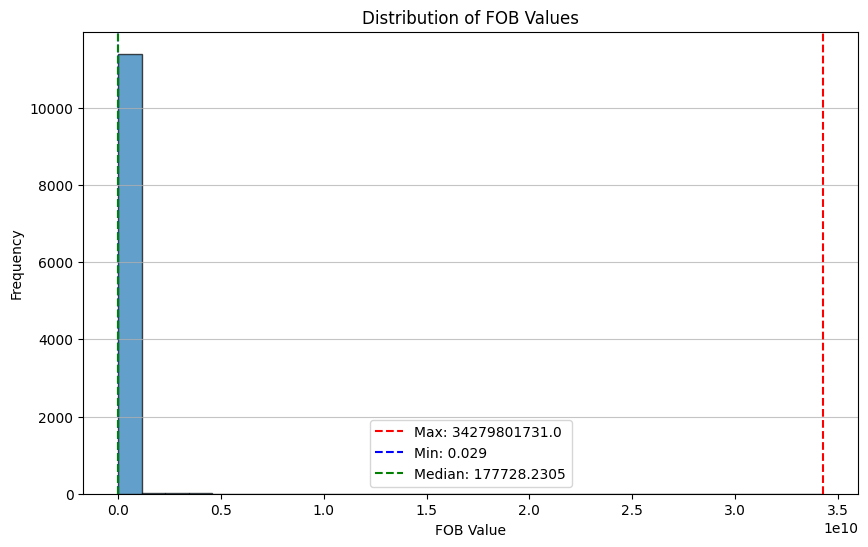

In [17]:
# FOB値(fobvalue)列の統計量を計算
max_value = df['fobvalue'].max()
min_value = df['fobvalue'].min()
median_value = df['fobvalue'].median()

# 統計量を表示
print(f"Maximum FOB Value: {max_value}")
print(f"Minimum FOB Value: {min_value}")
print(f"Median FOB Value: {median_value}")

# FOB値(fobvalue)列の分布を表示
plt.figure(figsize=(10, 6))
plt.hist(df['fobvalue'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of FOB Values')
plt.xlabel('FOB Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# 最大値、最小値、中央値をプロット
plt.axvline(max_value, color='red', linestyle='--', linewidth=1.5, label=f'Max: {max_value}')
plt.axvline(min_value, color='blue', linestyle='--', linewidth=1.5, label=f'Min: {min_value}')
plt.axvline(median_value, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_value}')

# 凡例を表示
plt.legend()
plt.show()


**要チェック：FOB値って単位何でExcelに載ってるんだ**

まず、reportedDescがWorldの行を削除する

In [18]:
df = df[df['reporterDesc'] != 'world']
df = df[df['partnerDesc'] != 'world']
# 結果を確認
print(f"Number of rows after filtering: {len(df)}")

Number of rows after filtering: 11454


そのうえでもう一度FOB値の分布確認

Maximum FOB Value (no log): 34279801731.0
Minimum FOB Value (no log): 0.029
Median FOB Value (no log): 177728.2305


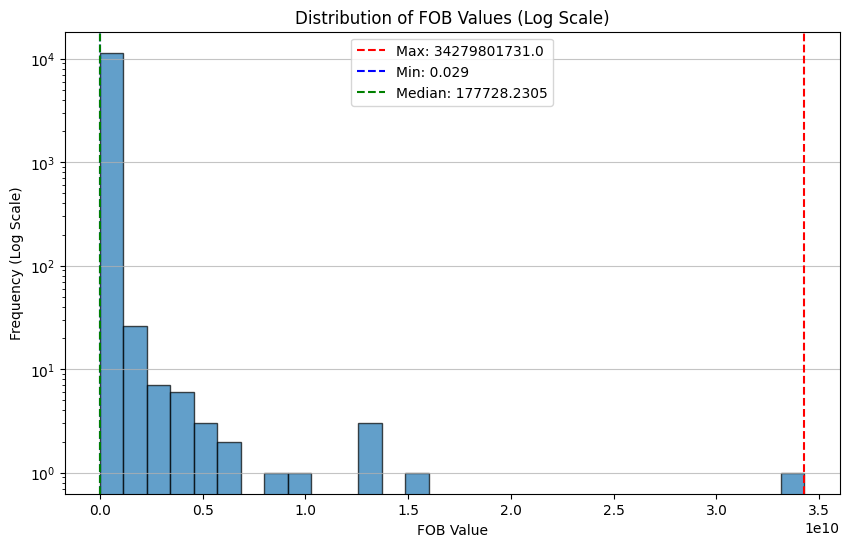

In [19]:
import numpy as np

# FOB値(fobvalue)列の統計量を計算
max_value = df['fobvalue'].max()
min_value = df['fobvalue'].min()
median_value = df['fobvalue'].median()

# 最大値、最小値、中央値を表示（対数変換なし）
print(f"Maximum FOB Value (no log): {max_value}")
print(f"Minimum FOB Value (no log): {min_value}")
print(f"Median FOB Value (no log): {median_value}")

# FOB値(fobvalue)列の分布を表示（対数スケール）
plt.figure(figsize=(10, 6))
plt.hist(df['fobvalue'], bins=30, edgecolor='black', alpha=0.7, log=True)
plt.title('Distribution of FOB Values (Log Scale)')
plt.xlabel('FOB Value')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', alpha=0.75)

# 最大値、最小値、中央値をプロット（対数スケールに変換してプロット）
plt.axvline(max_value, color='red', linestyle='--', linewidth=1.5, label=f'Max: {max_value}')
plt.axvline(min_value, color='blue', linestyle='--', linewidth=1.5, label=f'Min: {min_value}')
plt.axvline(median_value, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_value}')

# 凡例を表示
plt.legend()
plt.show()

まだ外れ値があるので何が外れているのか確認する

In [20]:
# FOB値が最大である行を抽出
max_row = df[df['fobvalue'] == max_value]

# 最大値を持つ行のreporterDescとpartnerDescを表示
reporter = max_row['reporterDesc'].values[0]
partner = max_row['partnerDesc'].values[0]

print(f"Reporter with max FOB value: {reporter}")
print(f"Partner with max FOB value: {partner}")

Reporter with max FOB value: China
Partner with max FOB value: World


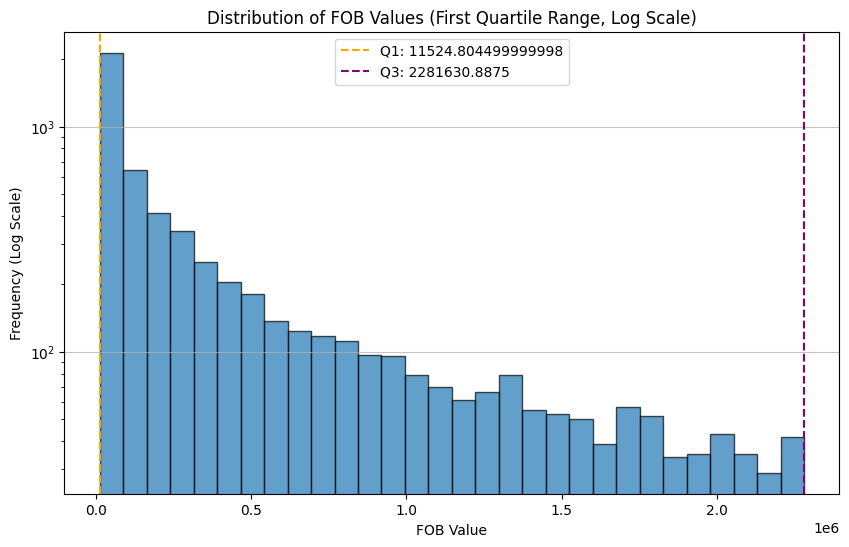

In [21]:
# FOB値の第一四分位範囲を計算
q1 = df['fobvalue'].quantile(0.25)
q3 = df['fobvalue'].quantile(0.75)

# 第一四分位範囲のデータを抽出
iqr_data = df[(df['fobvalue'] >= q1) & (df['fobvalue'] <= q3)]

# 抽出したデータの分布を表示（対数スケール）
plt.figure(figsize=(10, 6))
plt.hist(iqr_data['fobvalue'], bins=30, edgecolor='black', alpha=0.7, log=True)
plt.title('Distribution of FOB Values (First Quartile Range, Log Scale)')
plt.xlabel('FOB Value')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', alpha=0.75)

# 第一四分位範囲の境界線をプロット
plt.axvline(q1, color='orange', linestyle='--', linewidth=1.5, label=f'Q1: {q1}')
plt.axvline(q3, color='purple', linestyle='--', linewidth=1.5, label=f'Q3: {q3}')

# 凡例を表示
plt.legend()
plt.show()

・小さい値にデータ数が集まっているので、不用意に削除すると鉱物輸出量が少ないだけで主要な国同士とのやり取りである行を削除する恐れがある

・今はデータ数減らしたくない

↓

一旦そのまま使う

**カラム説明**

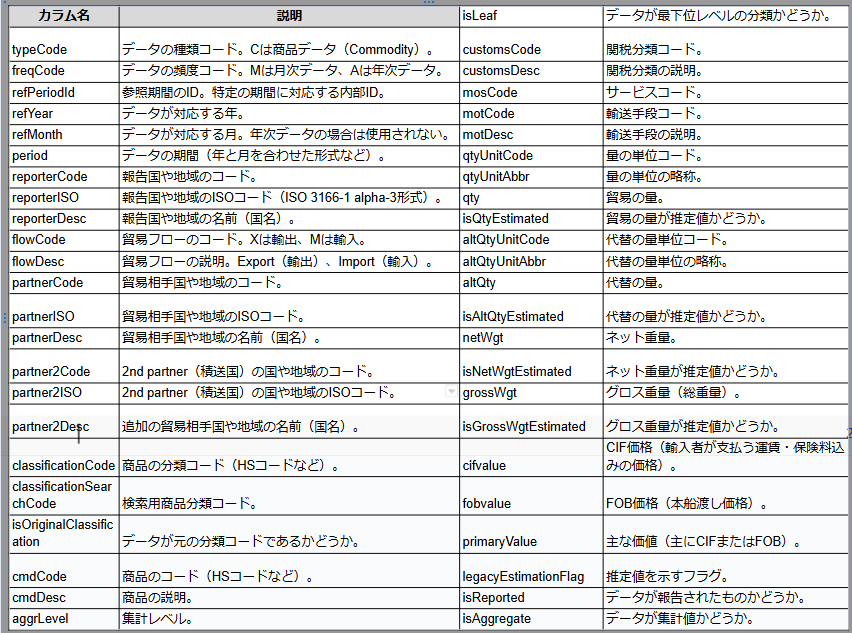

**2nd partner countryについて**
https://uncomtrade.org/docs/second-partner-country/

# 2. ネットワーク可視化

## 2-1. データをネットワーク構造に落とし込む

### ①UNcomtrade analysis.ipynb を参考にしたもの

In [22]:
# --------------------------------------------------
# Extract nodes (as dataframe)

#nodes = df['reporterDesc']

# --------------------------------------------------
# Extract edges (as dataframe)

#edges = df['fobvalue']

# --------------------------------------------------

In [25]:
#def create_graph(edges: pd.DataFrame) -> nx.DiGraph:
    """
    Create a single directed graph from the edges dataframe without layers.
    """
    # 列名をマッピング
    #source_col = "reporterDesc"  # ノード（出発側）の列名
    #target_col = "partnerDesc"  # ノード（到着側）の列名
    #weight_col = "fobvalue"     # 重み（貿易額）の列名

    # 単一グラフを作成
    #graph = nx.from_pandas_edgelist(
        #edges,
        #source=source_col,
        #target=target_col,
        #edge_attr=weight_col,
        #create_using=nx.DiGraph
    )
    #return graph

IndentationError: unexpected indent (<ipython-input-25-5e9a03626e2d>, line 2)

In [24]:
# Extract various graph properties (as dict)

#gprops_df = pd.read_csv(target + "/gprops.csv", on_bad_lines='skip')
#gprops_df.columns = gprops_df.columns.str.replace(" ", "")
#gprops_df.columns = gprops_df.columns.str.replace("#", "")

# make a dict object out of the gprops dataframe
#gprops = gprops_df.set_index("prop_name").to_dict()["value"]

# extract the layers keys (as a dict)
#layer_keys = {}
#for item in gprops["layer_key"] \
    #.replace(" ", "").replace("\n", "") \
    #.replace("{", "").replace("}", "") \
    #.split("',"):

    #keyvalue = item.split(":'")
    #layer_keys[int(keyvalue[0])] = keyvalue[1]

#gprops["layer_key"] = layer_keys

#del layer_keys, gprops_df

# --------------------------------------------------
# replace numeric index with textual names

# replace country indexes in edges
#edges["source"] = edges["source"].map(nodes["name"])
#edges["target"] = edges["target"].map(nodes["name"])

# replace commodity indexes in edges
#edges["layer"] = edges["layer"].map(gprops["layer_key"])

# set country name as node index
#nodes = nodes.set_index("name")

### ②ネットワーク本参照

Number of nodes: 240
Number of edges: 7757


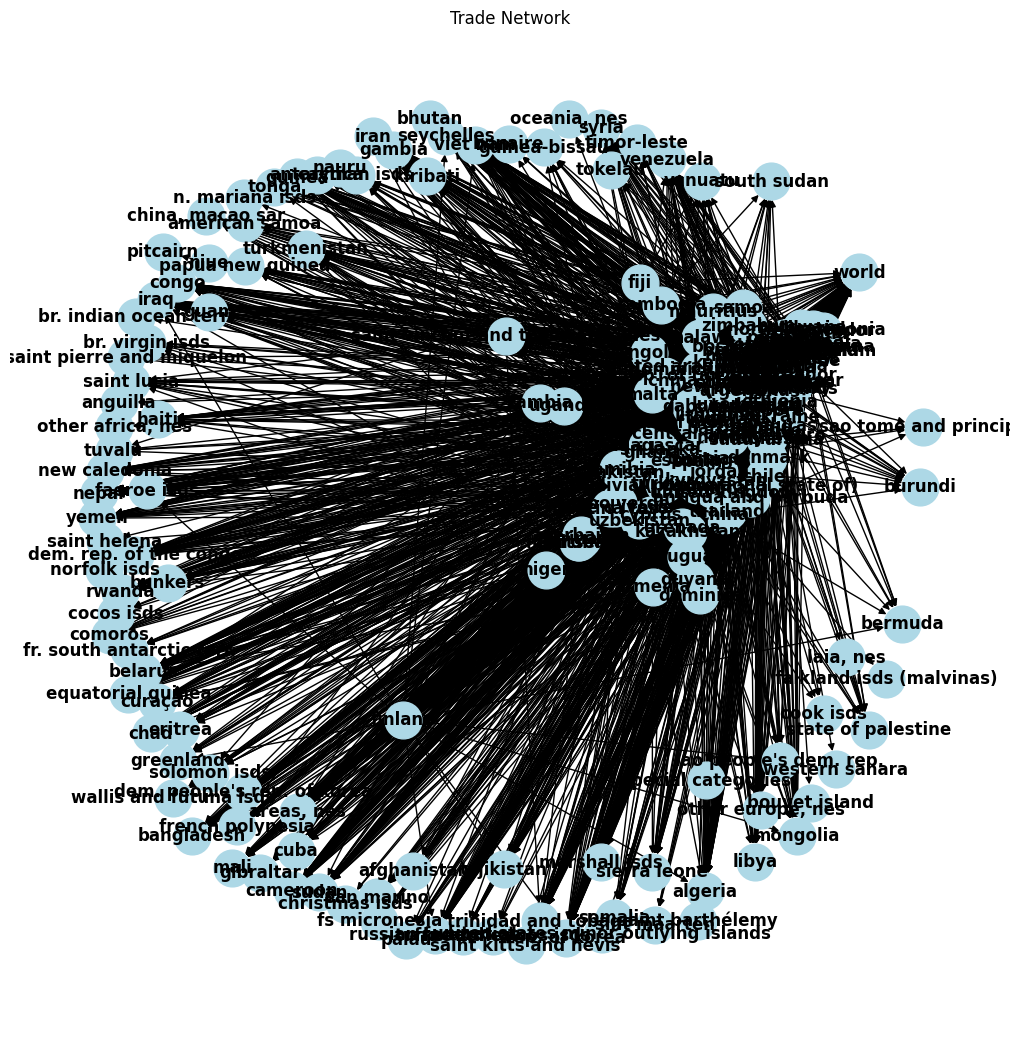

In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 必要な列のみ抽出（必要に応じて列名を調整）
df = df[["reporterDesc", "partnerDesc", "fobvalue"]]

# FOB値が0以下の場合は除外
df = df[df["fobvalue"] > 0]

# 重複を統一するため、すべてのノード名を小文字に変換
df["reporterDesc"] = df["reporterDesc"].str.lower()
df["partnerDesc"] = df["partnerDesc"].str.lower()

# NetworkXのグラフ作成
G = nx.DiGraph()  # 有向グラフ

# ノードとエッジを追加
for _, row in df.iterrows():
    reporter = row["reporterDesc"]
    partner = row["partnerDesc"]
    weight = row["fobvalue"]

    # ノード追加（重複ノードは自動的に統一）
    G.add_node(reporter)
    G.add_node(partner)

    # エッジ追加（FOB値が0以上の場合のみ）
    if weight > 0:
        G.add_edge(reporter, partner, weight=weight)

# グラフの情報を表示
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# グラフの描画
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)  # レイアウトを設定
nx.draw(
    G, pos, with_labels=True, node_size=700, node_color="lightblue", font_weight="bold"
)
plt.title("Trade Network")
plt.axis("off")
plt.show()


**▼中国を基点としたピラミッド型**

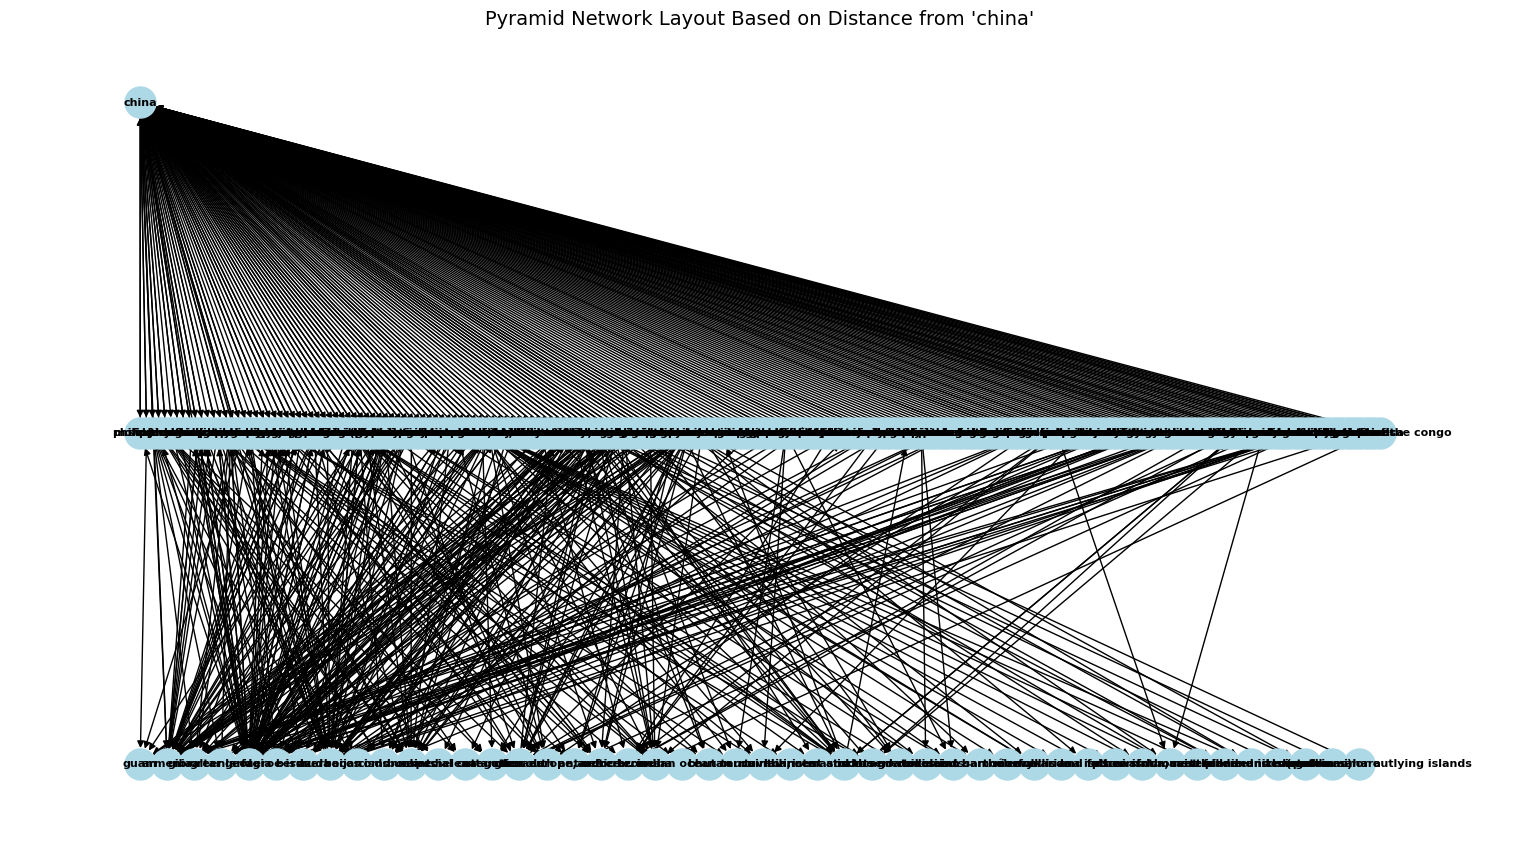

In [27]:
# 基点ノード
base_node = 'china'

# 各ノードのchinaからの距離を計算
if base_node in G:
    distances = nx.single_source_shortest_path_length(G, base_node)
else:
    raise ValueError(f"'{base_node}' not found in the graph nodes.")

# 距離に基づいてレイヤーを作成
layers = {}
for node, distance in distances.items():
    if distance not in layers:
        layers[distance] = []
    layers[distance].append(node)

# カスタムレイアウトの計算
pos = {}
layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
for distance in sorted(layers.keys()):
    layer_nodes = layers[distance]
    layer_x = 0.5  # x座標の開始点
    spacing = 1.0 / len(layer_nodes) if len(layer_nodes) > 0 else 1.0  # レイヤー内のノード間の間隔
    for i, node in enumerate(layer_nodes):
        pos[node] = (layer_x + i * spacing, layer_y)
    layer_y -= 0.2  # レイヤーを下げる（y座標）

# グラフの描画
# グラフの描画（横幅を広げ、ラベルの文字サイズを調整）
plt.figure(figsize=(15, 8))  # 横幅を広げる
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    node_color="lightblue",
    font_weight="bold",
    font_size=8  # ラベルの文字サイズを小さくする
)
plt.title("Pyramid Network Layout Based on Distance from 'china'", fontsize=14)
plt.axis('off')
plt.show()

二段にしか分かれていないから、おそらく中国を始点としたとき距離３以上の経路がないんだと思う。念のため確認。

In [28]:
# 基点ノード(china)からの距離を計算
distances = nx.single_source_shortest_path_length(G, "china")

# 距離が3以上のノードが存在するか確認
nodes_distance_3_or_more = {node: dist for node, dist in distances.items() if dist >= 3}

# 結果を表示
if nodes_distance_3_or_more:
    print("Nodes with distance 3 or more from 'china':")
    for node, distance in nodes_distance_3_or_more.items():
        print(f"Node: {node}, Distance: {distance}")
else:
    print("No nodes with distance 3 or more from 'china'.")

No nodes with distance 3 or more from 'china'.


次は終点をアメリカに限定して経路を描画したいけど、計算に時間がかかりすぎるので、中国→アメリカ経路のうち計算時間が現実的なものは距離いくつまで行けるのか計算してみる。
10、5、4とやってみたが4が現実的。

In [29]:
# 中国からアメリカまで行くすべてのパスを列挙（最大距離を10に制限）
all_paths = list(nx.all_simple_paths(G, source="china", target="usa", cutoff=4))

# 最も長いパス（ノード数が最大のパス）を取得
longest_path = max(all_paths, key=len)

# 最大パスのエッジ数を計算
max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# 結果を表示
print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
print(f"Number of edges in the longest path: {max_path_length}")

Longest path from 'china' to 'usa' (with max distance 10): ['china', 'morocco', 'india', 'mexico', 'usa']
Number of edges in the longest path: 4


**▼　始点：中国　→　終点：アメリカ　（距離４以下の経路）**

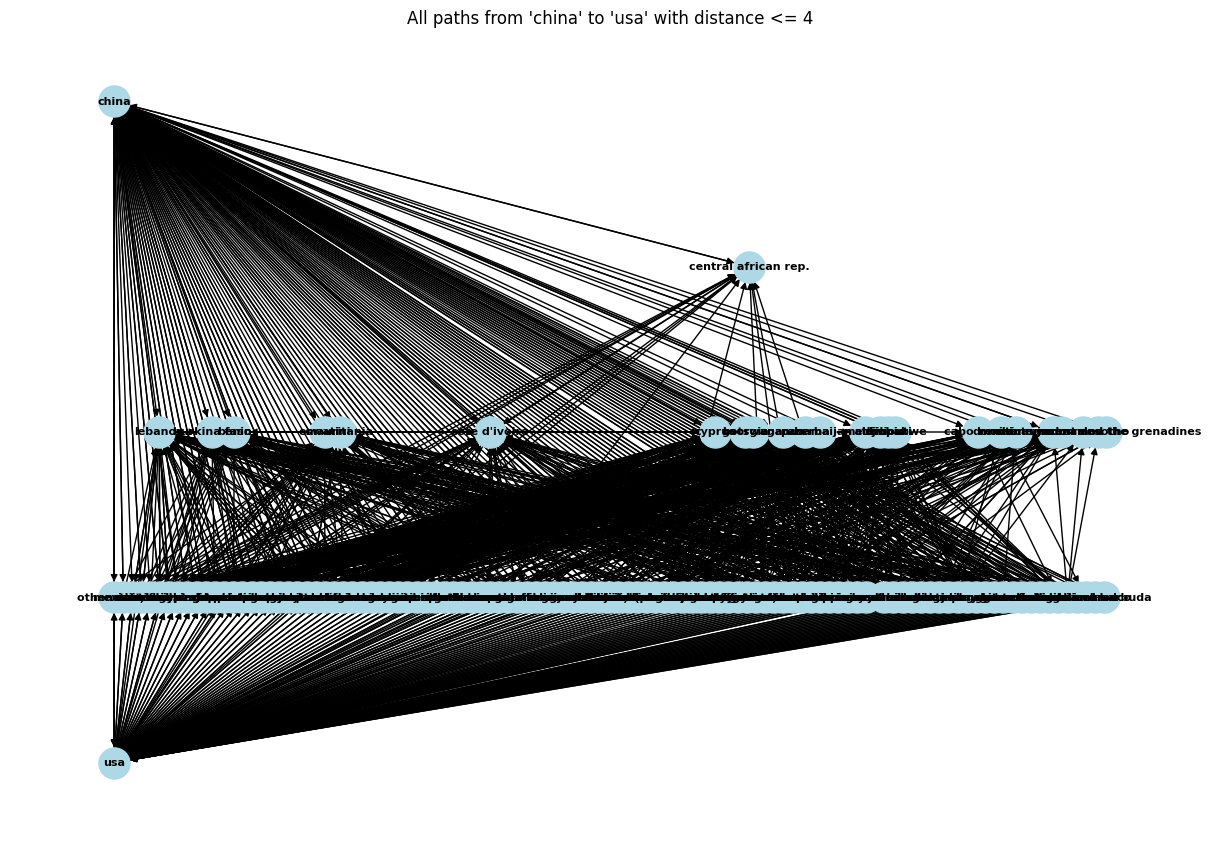

In [30]:
# 基点と終点を設定
source_node = "china"
target_node = "usa"

# 距離4以下の経路を抽出
paths_within_distance = list(nx.all_simple_paths(G, source=source_node, target=target_node, cutoff=4))

# 距離4以下の経路に含まれるすべてのノードを抽出
nodes_within_paths = set(node for path in paths_within_distance for node in path)

# サブグラフを作成（抽出したノードのみ含む）
subgraph = G.subgraph(nodes_within_paths)

# カスタムレイアウトの計算（レイヤー構造にする）
pos = {}
layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
layers = {}
for path in paths_within_distance:
    for distance, node in enumerate(path):
        if distance not in layers:
            layers[distance] = []
        if node not in layers[distance]:
            layers[distance].append(node)

for distance, nodes in sorted(layers.items()):
    layer_x = 0.5  # x座標の開始点
    spacing = 1.0 / len(nodes) if len(nodes) > 0 else 1.0  # レイヤー内のノード間隔
    for i, node in enumerate(nodes):
        pos[node] = (layer_x + i * spacing, layer_y)
    layer_y -= 0.2  # レイヤーを下げる

# グラフの描画
plt.figure(figsize=(12, 8))
nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=500,
    node_color="lightblue",
    font_weight="bold",
    font_size=8
)
plt.title(f"All paths from '{source_node}' to '{target_node}' with distance <= 4")
plt.axis('off')
plt.show()


In [31]:
# 中国からアメリカまでの距離4の経路を抽出
paths_with_distance_4 = [
    path for path in nx.all_simple_paths(G, source="china", target="usa", cutoff=4)
    if len(path) - 1 == 4  # 距離 = ノード数 - 1
]

# 結果を表示
print(f"Paths from 'china' to 'usa' with exact distance 4:")
for path in paths_with_distance_4:
    print(path)


Streaming output truncated to the last 5000 lines.
['china', 'greece', 'lithuania', 'belgium', 'usa']
['china', 'greece', 'lithuania', 'croatia', 'usa']
['china', 'greece', 'lithuania', 'israel', 'usa']
['china', 'greece', 'lithuania', 'south africa', 'usa']
['china', 'greece', 'lithuania', 'kyrgyzstan', 'usa']
['china', 'greece', 'lithuania', 'australia', 'usa']
['china', 'greece', 'lithuania', 'serbia', 'usa']
['china', 'greece', 'lithuania', 'philippines', 'usa']
['china', 'greece', 'lithuania', 'qatar', 'usa']
['china', 'greece', 'lithuania', 'czechia', 'usa']
['china', 'greece', 'lithuania', 'brazil', 'usa']
['china', 'greece', 'lithuania', 'rep. of moldova', 'usa']
['china', 'greece', 'lithuania', 'saudi arabia', 'usa']
['china', 'greece', 'lithuania', 'malta', 'usa']
['china', 'greece', 'lithuania', 'finland', 'usa']
['china', 'greece', 'lithuania', 'denmark', 'usa']
['china', 'greece', 'lithuania', 'nigeria', 'usa']
['china', 'greece', 'lithuania', 'north macedonia', 'usa']
['c

「中国からアメリカまでの距離4以下の経路」はめっちゃある。
たぶんグラフ上のレイヤーが4つにわかれた経路がcentral african repを通るものしかないのは、同じ描画上同じレイヤーの国同士で貿易しているから。

# 2.流入量計算＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊

オーストラリア（ISO36）からのレアアース類の総輸出額を100としたときの、直接または2か国までを経由した間接的なアルゼンチン（ISO32）への輸出額の割合を計算する

## Networkxで計算

In [33]:
# 中国を始点、アメリカを終点として輸出量/流入量で比例配分を計算するコード

def calculate_flow(G, source, target, weight='weight'):
    """
    中国を始点、アメリカを終点とし、ネットワーク上で比例配分に基づいて
    最終的なアメリカへの流入量を計算する関数。

    Parameters:
        G (nx.DiGraph): 重み付き有向グラフ
        source (str): 始点ノード（例: "china"）
        target (str): 終点ノード（例: "usa"）
        weight (str): 重み属性の名前（デフォルト: "weight"）

    Returns:
        float: アメリカへの流入量
    """
    # 初期化：全ノードの流入量を0、始点の流入量を1
    flow = {node: 0 for node in G.nodes}
    flow[source] = 1  # 始点の流入量を1に設定

    # トポロジカルソートでノードを巡回
    for node in nx.topological_sort(G):
        # 出力ノードがある場合
        out_edges = list(G.out_edges(node, data=True))
        if out_edges:
            total_weight = sum(edge[2][weight] for edge in out_edges)  # 総輸出量
            for _, neighbor, edge_data in out_edges:
                # 比例配分で隣接ノードに流入を分配
                proportion = edge_data[weight] / total_weight
                flow[neighbor] += flow[node] * proportion

    return flow[target]

# アメリカへの最終流入量を計算
usa_flow = calculate_flow(subgraph, source=source_node, target=target_node)

# 結果を表示
print(f"The calculated flow into '{target_node}' from '{source_node}' is: {usa_flow}")


NetworkXUnfeasible: Graph contains a cycle or graph changed during iteration

In [1]:
# サイクルを削除してDAGに変換
dag = nx.DiGraph()
dag.add_nodes_from(subgraph.nodes(data=True))
dag.add_edges_from(nx.edge_dfs(subgraph))

# アメリカへの最終流入量を計算
usa_flow = calculate_flow(dag, source=source_node, target=target_node)

# 結果を表示
print(f"The calculated flow into '{target_node}' from '{source_node}' is: {usa_flow}")

NameError: name 'nx' is not defined

In [34]:
# 中国からのすべてのノードへの距離を計算
distances = nx.single_source_shortest_path_length(subgraph, source_node)

# 各距離ごとにノードを分類
categories = {1: [], 2: [], 3: []}  # 一次、二次、三次経由国
for node, distance in distances.items():
    if node != target_node and 1 <= distance <= 3:  # アメリカを除外し、距離が1～3の範囲
        categories[distance].append(node)

# 結果を表示
print("Transit countries categorized by distance from China:")
for level, nodes in categories.items():
    print(f"{level}次経由国: {', '.join(nodes) if nodes else 'なし'}")


Transit countries categorized by distance from China:
1次経由国: morocco, philippines, finland, kenya, south africa, jamaica, serbia, nigeria, czechia, kazakhstan, hungary, poland, croatia, denmark, colombia, singapore, norway, cyprus, uzbekistan, china, hong kong sar, japan, switzerland, spain, ukraine, saudi arabia, slovakia, ireland, india, egypt, indonesia, israel, italy, ethiopia, bolivia (plurinational state of), brazil, estonia, mexico, argentina, brunei darussalam, myanmar, slovenia, portugal, romania, panama, pakistan, new zealand, netherlands, malaysia, malta, mauritius, kuwait, lebanon, latvia, sweden, tunisia, türkiye, thailand, united kingdom, other asia, nes, australia, austria, belgium, chile, canada, sri lanka, guatemala, germany, guyana, france, dominican rep., malawi, dominica, montenegro, togo, madagascar, ecuador, el salvador, senegal, united rep. of tanzania, fiji, rep. of moldova, central african rep., côte d'ivoire, suriname, jordan, zimbabwe, oman, samoa, iceland, n

##手計算

In [ ]:
# オーストラリアのレアアース類（HS28）の輸出データをフィルタリング
aus_rareearth = df[(df['reporterDesc'] == 'Australia') & (df['cmdCode'] == '28')]

# 総輸出額（すべての輸出先に対する穀物類の輸出額の合計）
total_exports = aus_rareearth['fobvalue'].sum()

# 直接アルゼンチンへの輸出額
ar_exports_direct = aus_rareearth[aus_rareearth['partnerDesc'] == 'Argentina']['fobvalue'].sum()

# オーストラリアから輸出された（アルゼンチン以外の）すべての国への輸出額
exports_to_other_countries = aus_rareearth[aus_rareearth['partnerDesc'] != 'Argentina']

# アルゼンチンへの間接輸出の推定
# 他国を経由した場合も考慮して、2国まで追跡
indirect_exports_to_ar_total = 0

# 1次経由国から2次経由国（アルゼンチンかどうか）への再輸出を確認
for index, row in exports_to_other_countries.iterrows():
    first_country = row['partnerDesc']
    export_value_to_first_country = row['fobvalue']

    # 1次経由国からのデータをフィルタリング（1次経由国から他国への輸出）
    first_country_exports = df[(df['reporterDesc'] == first_country) & (df['cmdCode'] == '28')]

    # 1次経由国からアルゼンチンへの輸出額
    exports_to_ar_from_first_country = first_country_exports[first_country_exports['partnerDesc'] == 'Argentina']['fobvalue'].sum()

    # 直接アルゼンチンへの再輸出割合を計算
    if export_value_to_first_country > 0:
        indirect_exports_to_ar_total += exports_to_ar_from_first_country

    # 2次経由も確認する
    for second_index, second_row in first_country_exports.iterrows():
        second_country = second_row['partnerDesc']
        export_value_to_second_country = second_row['fobvalue']

        if second_country != 'Argentina' and export_value_to_second_country > 0:
            # 2次経由国から米国への輸出を確認
            second_country_exports_to_ar = df[(df['reporterDesc'] == second_country) & (df['partnerDesc'] == 'Argentina') & (df['cmdCode'] == '28')]['fobvalue'].sum()

            # 2次経由国からの米国への再輸出割合を計算
            indirect_exports_to_ar_total += (second_country_exports_to_ar / export_value_to_second_country) * export_value_to_second_country

# アルゼンチンへの総輸出（直接輸出 + 間接輸出の推定）
total_ar_exports = ar_exports_direct + indirect_exports_to_ar_total

# アルゼンチンへの輸出割合を計算
ar_percentage = (total_ar_exports / total_exports) * 100

# 結果を表示
print(f"オーストラリアのレアアース類（HS28）の輸出額全体を100％としたとき、アルゼンチンへの（直接または2か国まで経由した）輸出は{ar_percentage:.2f}%です。")


In [ ]:
(ar_exports_direct/ total_exports) * 100

##2-2. NetworkXの計算・・・・・・・・・・・・・・・・・・・・・

In [ ]:
# グラフ初期化
G = nx.DiGraph()

# ノードとエッジの追加
for index, row in aus_rareearth.iterrows():
    reporter = row['reporterDesc']
    partner = row['partnerDesc']
    fobvalue = row['fobvalue']

    # ノード（国）を追加
    if reporter not in G:
        G.add_node(reporter)
    if partner not in G:
        G.add_node(partner)

    # エッジ（輸出フロー）を追加
    G.add_edge(reporter, partner, weight=fobvalue)

# アルゼンチンへのすべての輸出経路を探索する関数
def find_all_paths(graph, start, goal, max_hops):
    return list(nx.all_simple_paths(graph, start, goal, cutoff=max_hops))

# オーストラリアからアルゼンチンへの最大10経由までの経路を取得
max_hops = 10  # 最大経由数を設定
paths = find_all_paths(G, 'Australia', 'Argentina', max_hops)

# アルゼンチンへの直接および間接輸出額を計算
total_ar_exports = 0
for path in paths:
    export_value = float('inf')  # 経路の中で最小の輸出額を取得するため
    for i in range(len(path) - 1):
        edge_weight = G[path[i]][path[i + 1]]['weight']
        export_value = min(export_value, edge_weight)  # 最小値で経路全体を制約
    total_ar_exports += export_value  # 各経路の最小輸出額を合計

# オーストラリアの総輸出額（レアアース類）
total_exports = aus_rareearth['fobvalue'].sum()

# アルゼンチンへの輸出割合を計算
ar_percentage = (total_ar_exports / total_exports) * 100

# 結果を表示
print(f"オーストラリアのレアアース類（HS28）の輸出額全体を100％としたとき、アルゼンチンへの（直接または最大{max_hops}国経由した）輸出は{ar_percentage:.2f}%です。")


手計算のほうでは、経路ごとの最小輸出額ではなく単純に再輸出額を加算しているので、後者よりも大きくなってしまっているのだと思う。

### 2-2-2. ネットワーク図の表示

#### エッジ幅固定・ラベルなし

In [ ]:
# データフレームの確認とエッジの存在確認
if aus_rareearth.empty:
    print("Data is empty or filtered incorrectly.")
else:
    # グラフ初期化とノード・エッジの追加
    G = nx.DiGraph()
    for index, row in aus_rareearth.iterrows():
        reporter = row['reporterDesc']
        partner = row['partnerDesc']
        fobvalue = row['fobvalue']
        if fobvalue > 0:  # 輸出額が0以上の場合のみエッジを追加
            if reporter not in G:
                G.add_node(reporter)
            if partner not in G:
                G.add_node(partner)
            G.add_edge(reporter, partner, weight=fobvalue)

    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")

    # レイアウト調整
    pos = nx.spring_layout(G, seed=42, k=1.0)

    # ノードとエッジを描画
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(data=True), width=1)

    # ラベル表示を省略
    plt.title("Australia's Rare Earth Exports (HS28) Network (No Labels)")
    plt.show()

In [ ]:
# 全データ（オーストラリアに限定しない）を使用してレアアース類（HS28）の輸出データをフィルタリング
all_rareearth = df[df['cmdCode'] == '28']  # すべての国を対象にフィルタリング

# グラフを初期化
G = nx.DiGraph()

# ノードとエッジの追加
for index, row in all_rareearth.iterrows():
    reporter = row['reporterDesc']
    partner = row['partnerDesc']
    fobvalue = row['fobvalue']

    # ノード（国）を追加
    if reporter not in G:
        G.add_node(reporter)
    if partner not in G:
        G.add_node(partner)

    # エッジ（輸出フロー）を追加（輸出額が0以上のもののみ）
    if fobvalue > 0:
        G.add_edge(reporter, partner, weight=fobvalue)

# ノードとエッジの数を確認
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# ネットワーク図を描画する関数
def draw_network(graph):
    # ノード間の距離を調整
    pos = nx.spring_layout(graph, seed=42, k=1.0)

    # 図全体のサイズを大きく
    plt.figure(figsize=(10, 8))

    # ノードの描画
    nx.draw_networkx_nodes(graph, pos, node_size=100, node_color='lightblue')

    # エッジの描画（エッジ幅も縮小）
    nx.draw_networkx_edges(graph, pos, edgelist=graph.edges(data=True), width=1)

    # ラベル表示を省略
    plt.title("Global Rare Earth Exports (HS28) Network (No Labels)")
    plt.show()

# グラフを表示
draw_network(G)

やはりレアアースなので、数国がハブになっている

**今後の課題**



*   そもそも計算方法これでいいのか
*   データ量増やさないといけない。何回もリクエスト送って統合？
*   ネットワーク図表示してみたい（なんかうまくいかない）
*   中国と米国、レアアースでやってみる
*   制裁のタイミングと品目をちゃんと調べる
*   ネットワークの形状変化を見てみても面白いかもしれない（勉強中）





### 3. ネットワーク構造を把握する

### 3-1. グラフトポロジー計算

In [ ]:
# トポロジー情報を格納する辞書を初期化
topological = {}

# ノード数（ネットワークのサイズ）
topological["n"] = len(G.nodes)

# エッジ数（ネットワークのボリューム）
topological["m"] = len(G.edges)

# エッジの総重み（全エッジのweightの合計）
topological["tot_weight"] = sum([G.edges[e]['weight'] for e in G.edges])

# ネットワークの密度（完全グラフとの比較でのエッジの割合）
if topological["n"] > 1:
    topological["density"] = topological["m"] / (topological["n"] * (topological["n"] - 1))
else:
    topological["density"] = 0  # ノード数が1以下の場合は密度0とする

# ノードの平均次数（入次数と出次数を合わせた平均）
topological["avg_degree"] = sum(dict(G.degree()).values()) / topological["n"]

# 結果を表示
print(f"ノード数 (Size): {topological['n']}")
print(f"エッジ数 (Volume): {topological['m']}")
print(f"エッジの総重み (Total weight of edges): {topological['tot_weight']}")
print(f"ネットワークの密度 (Density): {round(topological['density'], 4)}")
print(f"平均次数 (Average degree): {round(topological['avg_degree'], 2)}")

In [ ]:
# Check if graph is connected
topological["weakly_connected"] = nx.is_weakly_connected(G)
topological["strongly_connected"] = nx.is_strongly_connected(G)

print("Weakly connected: ", topological["weakly_connected"])
print("Strongly connected: ", topological["strongly_connected"])

弱連結ではあるが強連結ではない

In [ ]:
# Find SCC and their sizes
scc = nx.strongly_connected_components(G)

scc_sizes = [len(c) for c in sorted(scc, key=len, reverse=True)]

unique, counts = np.unique(scc_sizes, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Nr. of SCC with {u} nodes: {c}")


print(f"{scc_sizes[0]}/{topological['n']} ({round(scc_sizes[0]/topological['n'], 2)*100}%) nodes are in the largest SCC")

サイズ１の強連結が197個、サイズ５の強連結が1個

In [ ]:
# ノードの次数を取得（出次数 + 入次数の合計）
degree_dict = dict(G.degree())

# ノードの次数が多い順に並べ替える
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

# ハブになっているノードの上位10国を取得
top_n = 10  # 上位何個のノードを取得するか設定
hub_nodes = [node for node, degree in sorted_degree[:top_n]]

# ハブノードを出力
print("ハブになっている国（上位10）：")
for hub in hub_nodes:
    print(hub)

In [ ]:
# 上位10国の次数（degree）を取得
hub_degrees = [degree for node, degree in sorted_degree[:top_n]]

# 棒グラフをプロット
plt.figure(figsize=(10, 6))
plt.bar(hub_nodes, hub_degrees, color='skyblue')  # 縦棒グラフを作成
plt.ylabel("Degree (Number of connections)")
plt.xlabel("Country (Node)")
plt.title(f"Top {top_n} Hub Countries by Degree")
plt.xticks(rotation=45, ha='right')  # 国名を45度回転して表示
plt.tight_layout()  # レイアウト調整
plt.show()


### 2024年9月19日　渡辺先生コメント
比例配分だとランダムでなにも想定していないことになるけど、
最小値で計算するとオーストラリアから入ったレアアースは優先的にアルゼンチンに入れていることになり、オーストラリアとアルゼンチンに特別な関係を想定することになってしまう。
按分だとランダムだからなにも想定はしていないことになる。
例えば、オーストラリアからのレアアース総輸出額を100として、

１リンク（直接）：そのうちの何割をアルゼンチンに輸出するか

２リンク：そのうちの何割をアルゼンチン以外の国（1次経由国）に輸出していて、1次経由国はレアアース輸出総量のうちの何割をアルゼンチンに輸出しているか

３リンク：そのうちの何割をアルゼンチン以外の国（1次経由国）に輸出していて、1次経由国はレアアース輸出総量の何割をアルゼンチン以外の国（2次経由国）に輸出していて、2次経由国はそのうちの何割をアルゼンチンに輸出しているのか


2リンク、3リンクの経路だけ先に洗い出しちゃって、そのうちの按分がどうなっているか、割合を見るのがいいんじゃないか。
中継国の候補の国のレアアースの分だけ先にもらっておく？

＜ここから何を言うか＞
流入額の総量は変わらないが、直接間接の割合が増えている、とか、直・間の割合の変化が言いたいことになる。

ありうることとしては、

・中国からの直・間合わせた流入量は変わっていない

・直・間組めても中国から買っていない（これは「国をスイッチしている」ということ。これが多くの人が想像するサンクションの影響）

いずれになるのか。

＜比較対象＞
直接（1リンク）はこれだけの流入割合、2リンクでこれだけ、3リンクでこれだけ、と表していくと、ある種の連続性があるような気がする。
そのパターンが分かるくらい先まで。もしかしたら3リンク以下よりも、制裁下では5リンク程度が流入割合がおおくなるかもしれない。

ネットワーク形状に関する統計量を見ることはできるかもしれないが、論文の冒頭でネットワークの形状がどう変化したかのあらましを語る程度にとどめて、直接間接の比率にあくまで比重を置くべき。


対照として、何も起きていない国がどううなってるかも見たほうがいいかも。
日英で同じ分析したときにどうなるかを標準として見せたほうがいい。
事件が起きなかったところも見ておかないと比較できない。


計算さえ乗り切れば何とかなりそうじゃないですか！

今後やること


1.   List item
2.   List it


## 2-3. 比例配分の式

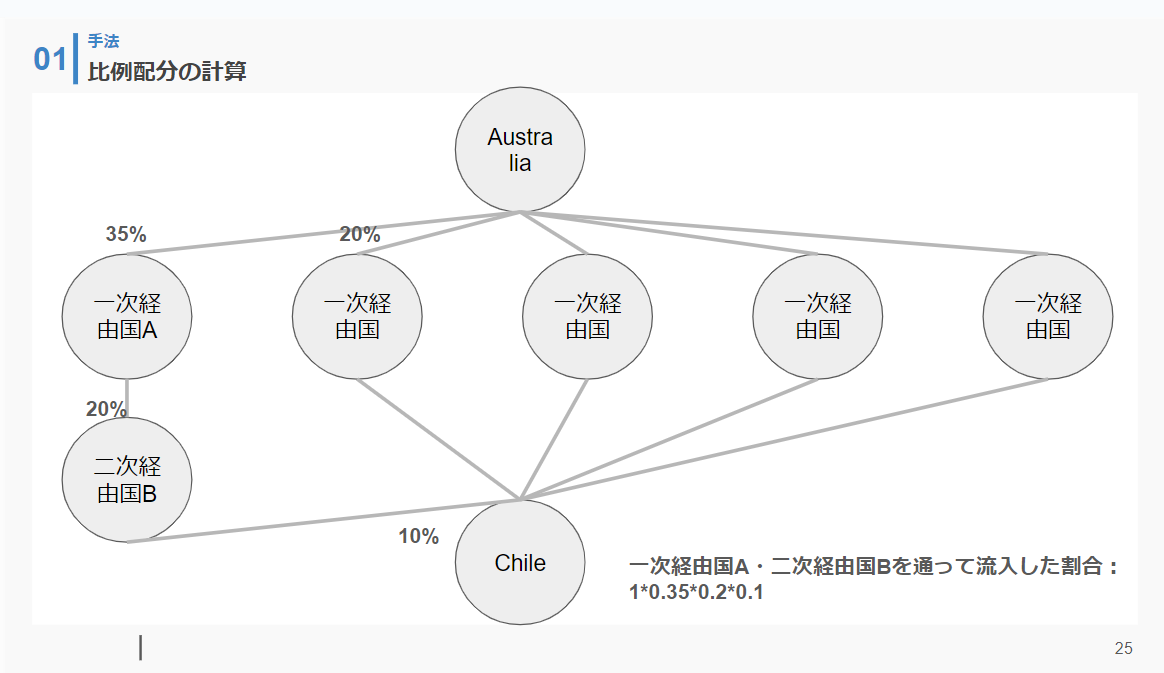

In [ ]:
import pandas as pd

# Australiaからの総輸出割合を100％と設定
aus_total_export_ratio = 1.0

# Australiaから直接Chileへの輸出割合と輸出額を取得
direct_to_chile_amount = df[(df['reporterDesc'] == 'Australia') & (df['partnerDesc'] == 'Chile')]['fobvalue'].sum()
aus_rare_amount = df[df['reporterDesc'] == 'Australia']['fobvalue'].sum()
direct_to_chile_ratio = direct_to_chile_amount / aus_rare_amount

# 再帰関数でn次経由までの疑似的な流出量を計算
def calculate_indirect_exports_ratio(df, origin, destination, current_amount, current_hop=1, max_hops=3):
    if current_hop > max_hops:
        return 0

    indirect_to_destination_amount = 0

    # 現在の経由国リストを取得（destination 以外への輸出のみ）
    current_hop_countries = df[(df['reporterDesc'] == origin) & (df['partnerDesc'] != destination)]

    for _, row in current_hop_countries.iterrows():
        next_country = row['partnerDesc']
        export_value_to_next = row['fobvalue']

        # 一次経由国への流出比率
        current_country_total_export = df[df['reporterDesc'] == origin]['fobvalue'].sum()
        current_ratio_to_next = export_value_to_next / current_country_total_export
        next_outflow = current_amount * current_ratio_to_next

        # 次の経由国から目的地への輸出割合
        destination_ratio = df[(df['reporterDesc'] == next_country) & (df['partnerDesc'] == destination)]['fobvalue'].sum() / df[df['reporterDesc'] == next_country]['fobvalue'].sum()

        # 次の経由国経由での疑似流入額を計算
        if pd.notna(destination_ratio):
            indirect_to_destination_amount += next_outflow * destination_ratio

        # 次の経由国について再帰的に計算
        indirect_to_destination_amount += calculate_indirect_exports_ratio(
            df,
            next_country,
            destination,
            next_outflow,
            current_hop + 1,
            max_hops
        )

    return indirect_to_destination_amount

# 経由ごとの流入額を計算
max_hops = 4  # nを希望の経由数に設定

# 1次経由のみ考慮
indirect_to_chile_1_hop_amount = calculate_indirect_exports_ratio(df, 'Australia', 'Chile', aus_total_export_ratio * aus_rare_amount, max_hops=1)

# 2次経由まで考慮
indirect_to_chile_2_hop_amount = calculate_indirect_exports_ratio(df, 'Australia', 'Chile', aus_total_export_ratio * aus_rare_amount, max_hops=2)

# n次経由まで考慮
indirect_to_chile_n_hop_amount = calculate_indirect_exports_ratio(df, 'Australia', 'Chile', aus_total_export_ratio * aus_rare_amount, max_hops=max_hops)

# すべて考慮（直接 + n次経由まで）
total_export_to_chile_amount = direct_to_chile_amount + indirect_to_chile_n_hop_amount

# 結果を表示
print(f"Australia の rare earth の総輸出額: {aus_rare_amount}")
print(f"Australia から Chile への直接流入割合: {direct_to_chile_ratio:.4f}, 流入額: {direct_to_chile_amount:.4f}")
print(f"Australia から Chile への1次経由流入額: {indirect_to_chile_1_hop_amount:.4f}")
print(f"Australia から Chile への2次経由流入額: {indirect_to_chile_2_hop_amount:.4f}")
print(f"Australia から Chile への{max_hops}次経由流入額: {indirect_to_chile_n_hop_amount:.4f}")
print(f"Australia から Chile への総流入額（直接 + {max_hops}次経由含む）: {total_export_to_chile_amount:.4f}")


** 結果について **
- 直接流入以外の経路においては、疑似的に、（経由国の全輸出量に占める目的国への流入割合）を

**To Do**
- Bulk Downloadの方法調べる
- 経済制裁の年表
- 計算沢山やってみる

先生のアドバイス

最短経路帳を作れ
3リンクぐらいまで
